In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors, rdFingerprintGenerator

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, roc_auc_score, accuracy_score, confusion_matrix, roc_curve)

RDLogger.DisableLog('rdApp.*')

In [59]:
df = pd.read_csv(r'C:\Users\DANISH LAPTOP\OneDrive\Desktop\BBBP.csv')

# Drop missing SMILES entries
df_clean = df.dropna(subset=['smiles']).copy()
print(f"Total Valid SMILES Loaded: {len(df_clean)}")

Total Valid SMILES Loaded: 2039


In [60]:
df.head()

,Column1,num,name,p_np,smiles
0,0,1,Propanolol,1,CC(C)NCC(O)COC1:C:C:C:C2:C:C:C:C:C:1:2.[Cl]
1,1,2,Terbutylchlorambucil,1,CC(C)(C)OC(=O)CCCC1:C:C:C(N(CCCl)CCCl):C:C:1
2,2,3,40730,1,CC1COC2:C(N3CCN(C)CC3):C(F):C:C3:C(=O):C(C(=O)...
3,3,4,24,1,CC(=O)NCCCOC1:C:C:C:C(CN2CCCCC2):C:1
4,4,5,cloxacillin,1,CC1:O:N:C(C2:C:C:C:C:C:2Cl):C:1C(=O)N[C@@H]1C(...


In [61]:
# Extract descriptors for visualization
mws, logps, tpsas, hbds, hbas, rots = [], [], [], [], [], []

for s in df_clean['smiles']:
    mol = Chem.MolFromSmiles(s)
    if mol:
        mws.append(Descriptors.MolWt(mol))
        logps.append(Descriptors.MolLogP(mol))
        tpsas.append(Descriptors.TPSA(mol))
        hbds.append(Descriptors.NumHDonors(mol))
        hbas.append(Descriptors.NumHAcceptors(mol))
        rots.append(Descriptors.NumRotatableBonds(mol))

df_clean['Molecular_Weight'] = mws
df_clean['LogP'] = logps
df_clean['TPSA'] = tpsas
df_clean['H_Bond_Donors'] = hbds
df_clean['H_Bond_Acceptors'] = hbas
df_clean['Rotatable_Bonds'] = rots
df_clean['BBB_Status'] = df_clean['p_np'].map({1: 'Permeable (1)', 0: 'Non-permeable (0)'})

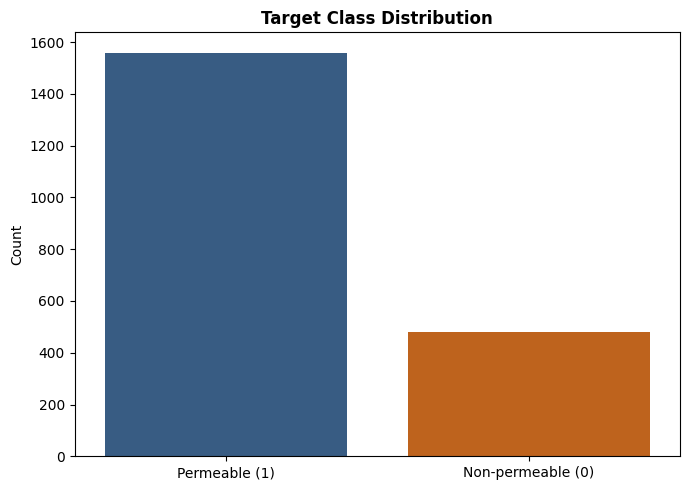

In [62]:
# Plot 1: Target Class Distribution
plt.figure(figsize=(7, 5))
sns.countplot(data=df_clean, x='BBB_Status', hue='BBB_Status', palette=['#2b5c8f', '#d95f02'],legend=False)
plt.title('Target Class Distribution', fontsize=12, fontweight='bold')
plt.xlabel('')
plt.ylabel('Count', fontsize=10)
plt.tight_layout()
plt.show()

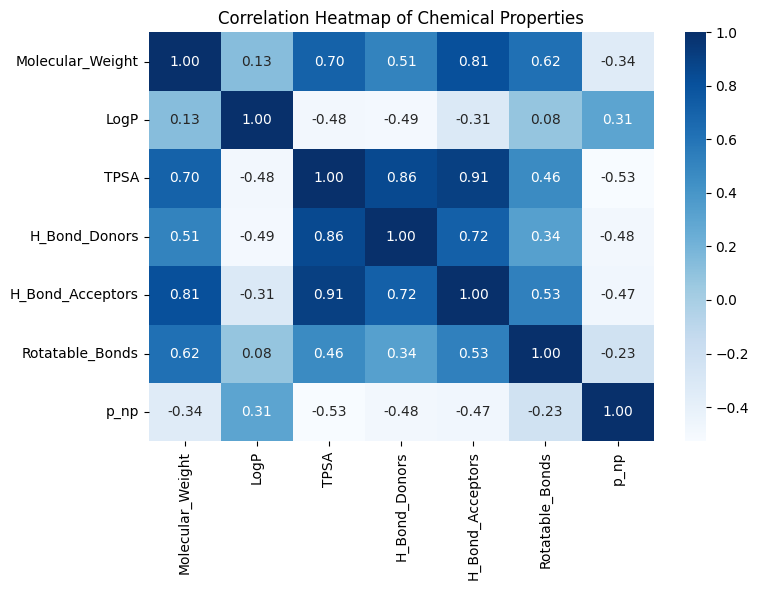

In [63]:

# 2. Now run Plot 2 (Correlation Heatmap)
plt.figure(figsize=(8, 6))
corr = df_clean[['Molecular_Weight', 'LogP', 'TPSA', 'H_Bond_Donors', 'H_Bond_Acceptors', 'Rotatable_Bonds', 'p_np']].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='Blues', cbar=True)
plt.title('Correlation Heatmap of Chemical Properties')
plt.tight_layout()
plt.show()

In [64]:
mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)

X_list = []
Y_list = []

for idx, row in df_clean.iterrows():
    mol = Chem.MolFromSmiles(row['smiles'])
    if mol is not None:
        fp_np = np.array(mfpgen.GetFingerprint(mol))
        
        mw = Descriptors.MolWt(mol)
        logp = Descriptors.MolLogP(mol)
        tpsa = Descriptors.TPSA(mol)
        hbd = Descriptors.NumHDonors(mol)
        hba = Descriptors.NumHAcceptors(mol)
        rot = Descriptors.NumRotatableBonds(mol)
        
        phys_desc = np.array([mw, logp, tpsa, hbd, hba, rot])
        combined_features = np.hstack((fp_np, phys_desc))
        
        X_list.append(combined_features)
        Y_list.append(row['p_np'])

X = np.array(X_list)
Y = np.array(Y_list)

In [65]:
mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)

X_list = []
Y_list = []
for idx, row in df_clean.iterrows():
    mol = Chem.MolFromSmiles(row['smiles'])
    if mol is not None:
        fp_np = np.array(mfpgen.GetFingerprint(mol))
        
        mw = Descriptors.MolWt(mol)
        logp = Descriptors.MolLogP(mol)
        tpsa = Descriptors.TPSA(mol)
        hbd = Descriptors.NumHDonors(mol)
        hba = Descriptors.NumHAcceptors(mol)
        rot = Descriptors.NumRotatableBonds(mol)
        
        phys_desc = np.array([mw, logp, tpsa, hbd, hba, rot])
        combined_features = np.hstack((fp_np, phys_desc))
        
        X_list.append(combined_features)
        Y_list.append(row['p_np'])
X = np.array(X_list)
Y = np.array(y_list)

In [67]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

In [25]:
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, Y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [68]:
Y_pred = model.predict(X_test)
Y_probs = model.predict_proba(X_test)[:, 1]

print("=== Blood Brain Barrier Penetration PERFORMANCE ===")
print(f"Accuracy: {accuracy_score(Y_test, Y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(Y_test, Y_probs):.4f}\n")
print(classification_report(Y_test, Y_pred, target_names=['Non-permeable (0)', 'Permeable (1)']))

=== Blood Brain Barrier Penetration PERFORMANCE ===
Accuracy: 0.8971
ROC-AUC: 0.9518

                   precision    recall  f1-score   support

Non-permeable (0)       0.88      0.66      0.75        96
    Permeable (1)       0.90      0.97      0.94       312

         accuracy                           0.90       408
        macro avg       0.89      0.81      0.84       408
     weighted avg       0.90      0.90      0.89       408



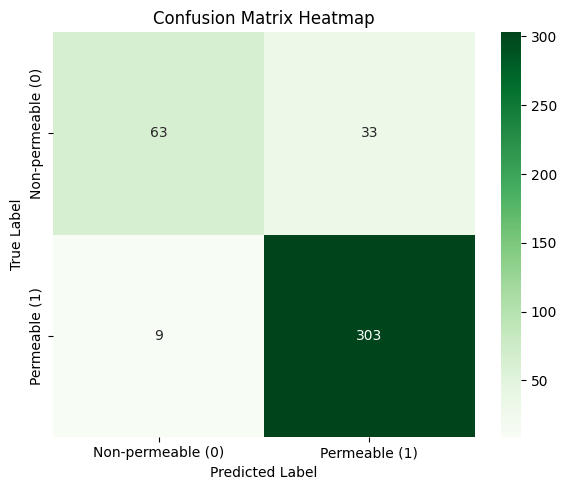

In [69]:
cm = confusion_matrix(Y_test, Y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Greens',
    xticklabels=['Non-permeable (0)', 'Permeable (1)'],
    yticklabels=['Non-permeable (0)', 'Permeable (1)']
)
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

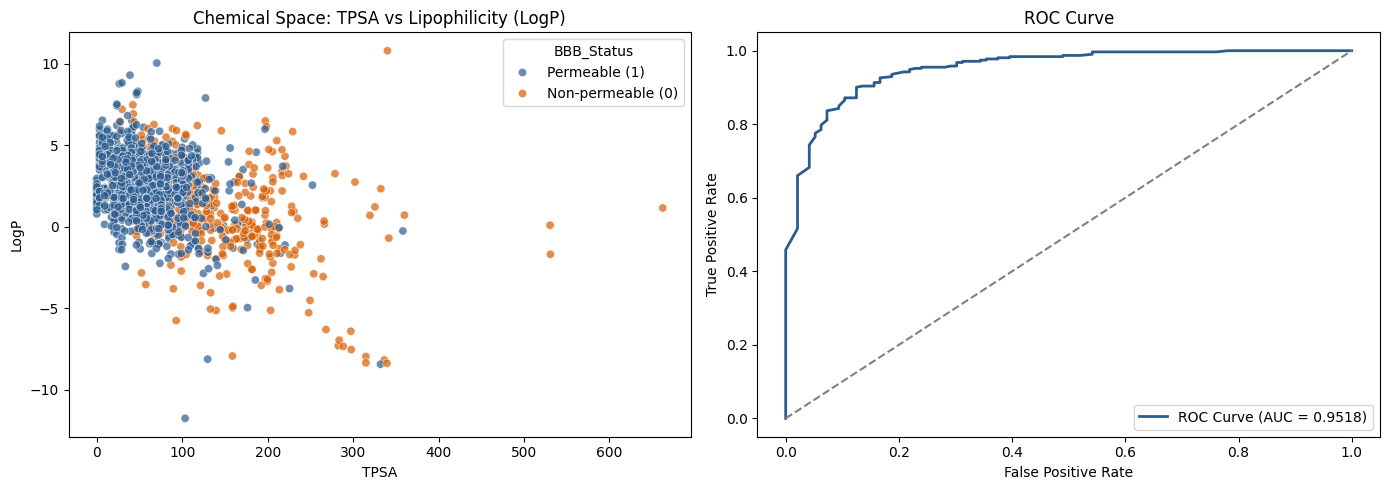

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Chemical Space Scatter Plot
sns.scatterplot(
    data=df_clean, x='TPSA', y='LogP', hue='BBB_Status', 
    alpha=0.7, ax=axes[0], palette=['#2b5c8f', '#d95f02']
)
axes[0].set_title('Chemical Space: TPSA vs Lipophilicity (LogP)')

# 2. Receiver Operating Characteristic (ROC) Curve
fpr, tpr, _ = roc_curve(Y_test, Y_probs)
auc_score = roc_auc_score(Y_test, Y_probs)

axes[1].plot(fpr, tpr, color='#2b5c8f', lw=2, label=f'ROC Curve (AUC = {auc_score:.4f})')
axes[1].plot([0, 1], [0, 1], color='grey', linestyle='--')
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

In [71]:
def predict_molecule_bbb(smiles_string):
    mol = Chem.MolFromSmiles(smiles_string)
    if mol is None:
        return "Invalid SMILES String!"
    
    fp_np = np.array(mfpgen.GetFingerprint(mol))
    phys_desc = np.array([
        Descriptors.MolWt(mol),
        Descriptors.MolLogP(mol),
        Descriptors.TPSA(mol),
        Descriptors.NumHDonors(mol),
        Descriptors.NumHAcceptors(mol),
        Descriptors.NumRotatableBonds(mol)
    ])
    
    features = np.hstack((fp_np, phys_desc)).reshape(1, -1)
    
    prob = model.predict_proba(features)[0][1]
    pred = model.predict(features)[0]
    
    status = "Permeable (Crosses BBB)" if pred == 1 else "Non-permeable (Blocked)"
    return f"Prediction: {status} | Probability: {prob * 100:.2f}%"

# Sample Test Molecules
test_molecules = {
    "Caffeine": "CN1C=NC2=C1C(=O)N(C(=O)N2C)C",
    "Aspirin": "CC(=O)OC1=CC=CC=C1C(=O)O",
    "Dopamine": "C1=CC(=C(C=C1CCN)O)O",
    "Ibuprofen": "CC(C)CC1=CC=C(C=C1)C(C)C(=O)O",
    "Penicillin G": "CC1(C(N2C(S1)C(C2=O)NC(=O)CC3=CC=CC=C3)C(=O)O)C"
}

print("\n--- Additional Compounds ---")
for name, smiles in test_molecules.items():
    print(f"{name:15}: {predict_molecule_bbb(smiles)}")


--- Additional Compounds ---
Caffeine       : Prediction: Permeable (Crosses BBB) | Probability: 98.00%
Aspirin        : Prediction: Non-permeable (Blocked) | Probability: 29.00%
Dopamine       : Prediction: Non-permeable (Blocked) | Probability: 22.23%
Ibuprofen      : Prediction: Non-permeable (Blocked) | Probability: 25.23%
Penicillin G   : Prediction: Non-permeable (Blocked) | Probability: 12.48%


In [72]:
joblib.dump(model, 'bbb_penetration_rf_model.pkl')
print("Model saved successfully as 'bbb_penetration_rf_model.pkl'")

Model saved successfully as 'bbb_penetration_rf_model.pkl'
